In [2]:
# ============================================
# MDI3003 - Lab 02: Medical Diagnosis Support
# Disease Classification Using Decision Trees
# ============================================
!pip install -q numpy pandas matplotlib seaborn scikit-learn ucimlrepo joblib

import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer, fetch_openml
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV,
    cross_validate, cross_val_predict, GroupKFold
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, matthews_corrcoef, brier_score_loss,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
import joblib

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("\n" + "="*70)
print("ENVIRONMENT SETUP COMPLETE")
print("="*70)
print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print("="*70)


ENVIRONMENT SETUP COMPLETE
Python: 3.12.13
NumPy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1


DATASET 1: BREAST CANCER WISCONSIN (DIAGNOSTIC)

1.1 LOADING DATASET...
Shape: (569, 30)
Features: 30
Positive class (Malignant): 212
Negative class (Benign): 357
Prevalence: 0.373

1.2 DATA AUDIT...
                   dtype  missing  unique        min        max
mean radius      float64        0     456    6.98100    28.1100
mean texture     float64        0     479    9.71000    39.2800
mean perimeter   float64        0     522   43.79000   188.5000
mean area        float64        0     539  143.50000  2501.0000
mean smoothness  float64        0     474    0.05263     0.1634

Duplicate rows: 0
Constant columns: []

1.3 SPLITTING DATA...
Training: 455 samples
Test: 114 samples
Training prevalence: 0.374
Test prevalence: 0.368

1.4 EXPLORATORY DATA ANALYSIS...


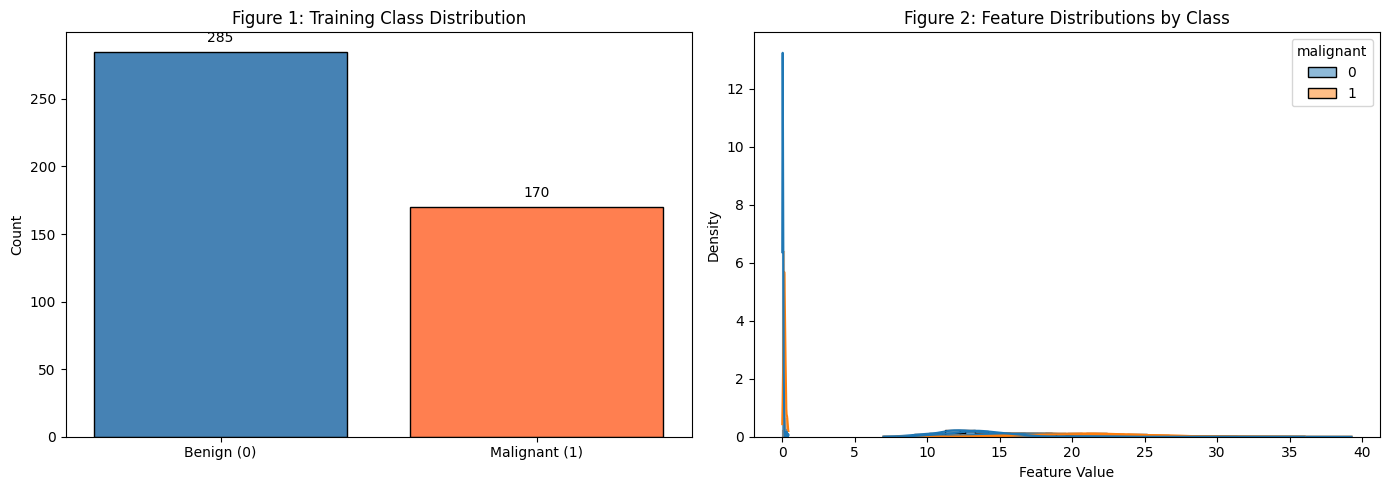

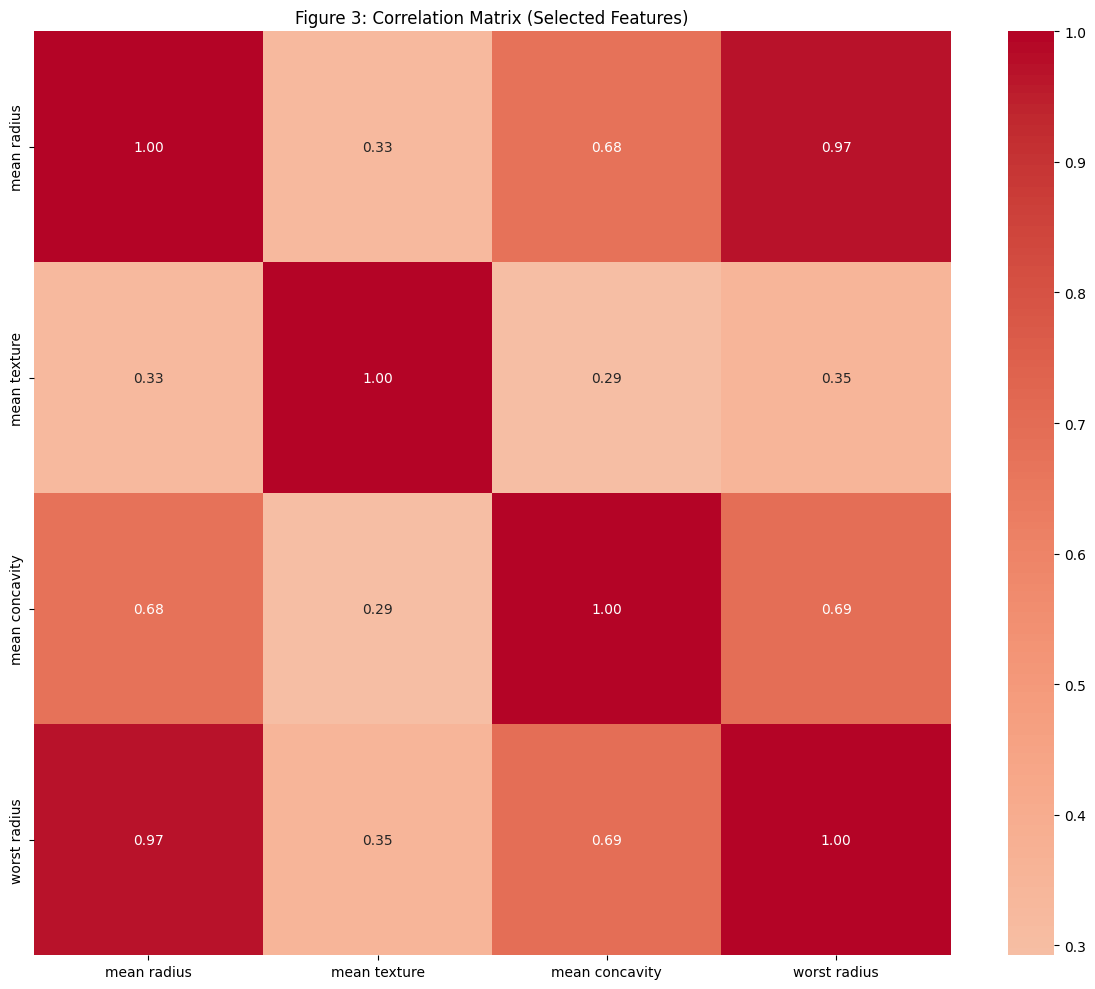

In [3]:
# ============================================
# DATASET 1: BREAST CANCER WISCONSIN (DIAGNOSTIC)
# ============================================

print("DATASET 1: BREAST CANCER WISCONSIN (DIAGNOSTIC)")


# 1.1 Load Dataset
print("\n1.1 LOADING DATASET...")
data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y = (data.target == 0).astype(int)  # Malignant = 1, Benign = 0
y.name = "malignant"

print(f"Shape: {X.shape}")
print(f"Features: {len(X.columns)}")
print(f"Positive class (Malignant): {y.sum()}")
print(f"Negative class (Benign): {len(y) - y.sum()}")
print(f"Prevalence: {y.mean():.3f}")

# 1.2 Data Audit
print("\n1.2 DATA AUDIT...")
audit = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing": X.isna().sum(),
    "unique": X.nunique(),
    "min": X.min(numeric_only=True),
    "max": X.max(numeric_only=True),
})
print(audit.head())
print(f"\nDuplicate rows: {X.duplicated().sum()}")
print(f"Constant columns: {X.columns[X.nunique() <= 1].tolist()}")

# 1.3 Train-Test Split
print("\n1.3 SPLITTING DATA...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Training: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")
print(f"Training prevalence: {y_train.mean():.3f}")
print(f"Test prevalence: {y_test.mean():.3f}")

# 1.4 EDA - Class Distribution
print("\n1.4 EXPLORATORY DATA ANALYSIS...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
class_counts = y_train.value_counts().sort_index()
axes[0].bar(["Benign (0)", "Malignant (1)"], class_counts.values,
            color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Figure 1: Training Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom')

# Feature distributions by class
selected_features = ['mean radius', 'mean texture', 'mean concavity', 'worst radius']
eda_df = X_train[selected_features].copy()
eda_df['malignant'] = y_train.values

for idx, feature in enumerate(selected_features):
    sns.histplot(data=eda_df, x=feature, hue='malignant', kde=True,
                 stat='density', common_norm=False, ax=axes[1] if idx == 0 else None)
    if idx == 0:
        axes[1].set_title('Figure 2: Feature Distributions by Class')
        axes[1].set_xlabel('Feature Value')
        axes[1].set_ylabel('Density')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 10))
corr_matrix = X_train[selected_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Figure 3: Correlation Matrix (Selected Features)')
plt.tight_layout()
plt.show()


MODEL 1: DUMMY CLASSIFIER (BASELINE)
         Model       ROC-AUC   Sensitivity  Balanced Acc
Dummy Baseline 0.500 ± 0.000 0.000 ± 0.000 0.500 ± 0.000

MODEL 2: BASIC CART (UNPRUNED)

Tree depth: 8
Number of leaves: 24
Number of nodes: 47
     Model       ROC-AUC   Sensitivity  Balanced Acc
Basic CART 0.917 ± 0.038 0.894 ± 0.061 0.917 ± 0.038


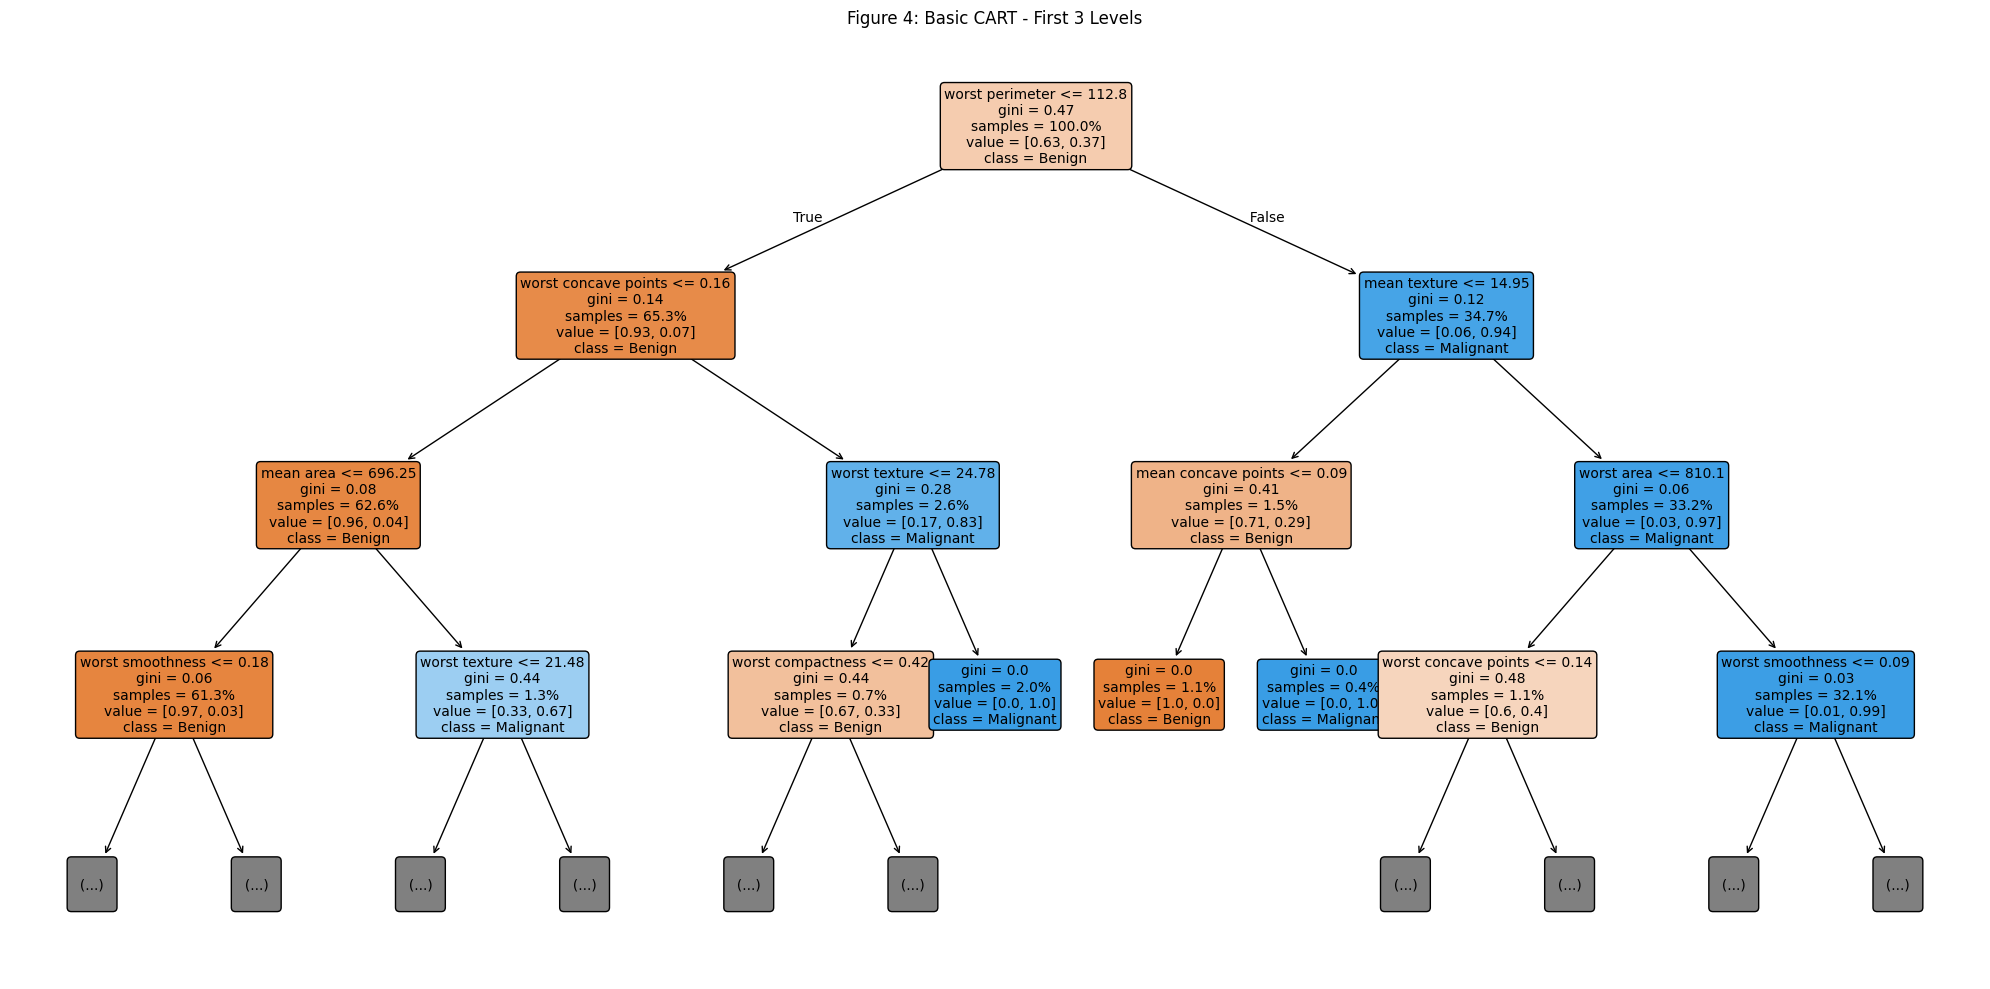


MODEL 3: TUNED AND PRUNED CART

3.1 TUNING PRE-PRUNING PARAMETERS...
Best pre-pruning params: {'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 4, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Best CV ROC-AUC: 0.975

3.2 COST-COMPLEXITY PRUNING...
Selected ccp_alpha: 0.000000
Pruned CV ROC-AUC: 0.917

Pruned tree depth: 8
Pruned tree leaves: 24
              Model       ROC-AUC   Sensitivity  Balanced Acc
Tuned & Pruned CART 0.917 ± 0.038 0.894 ± 0.061 0.917 ± 0.038


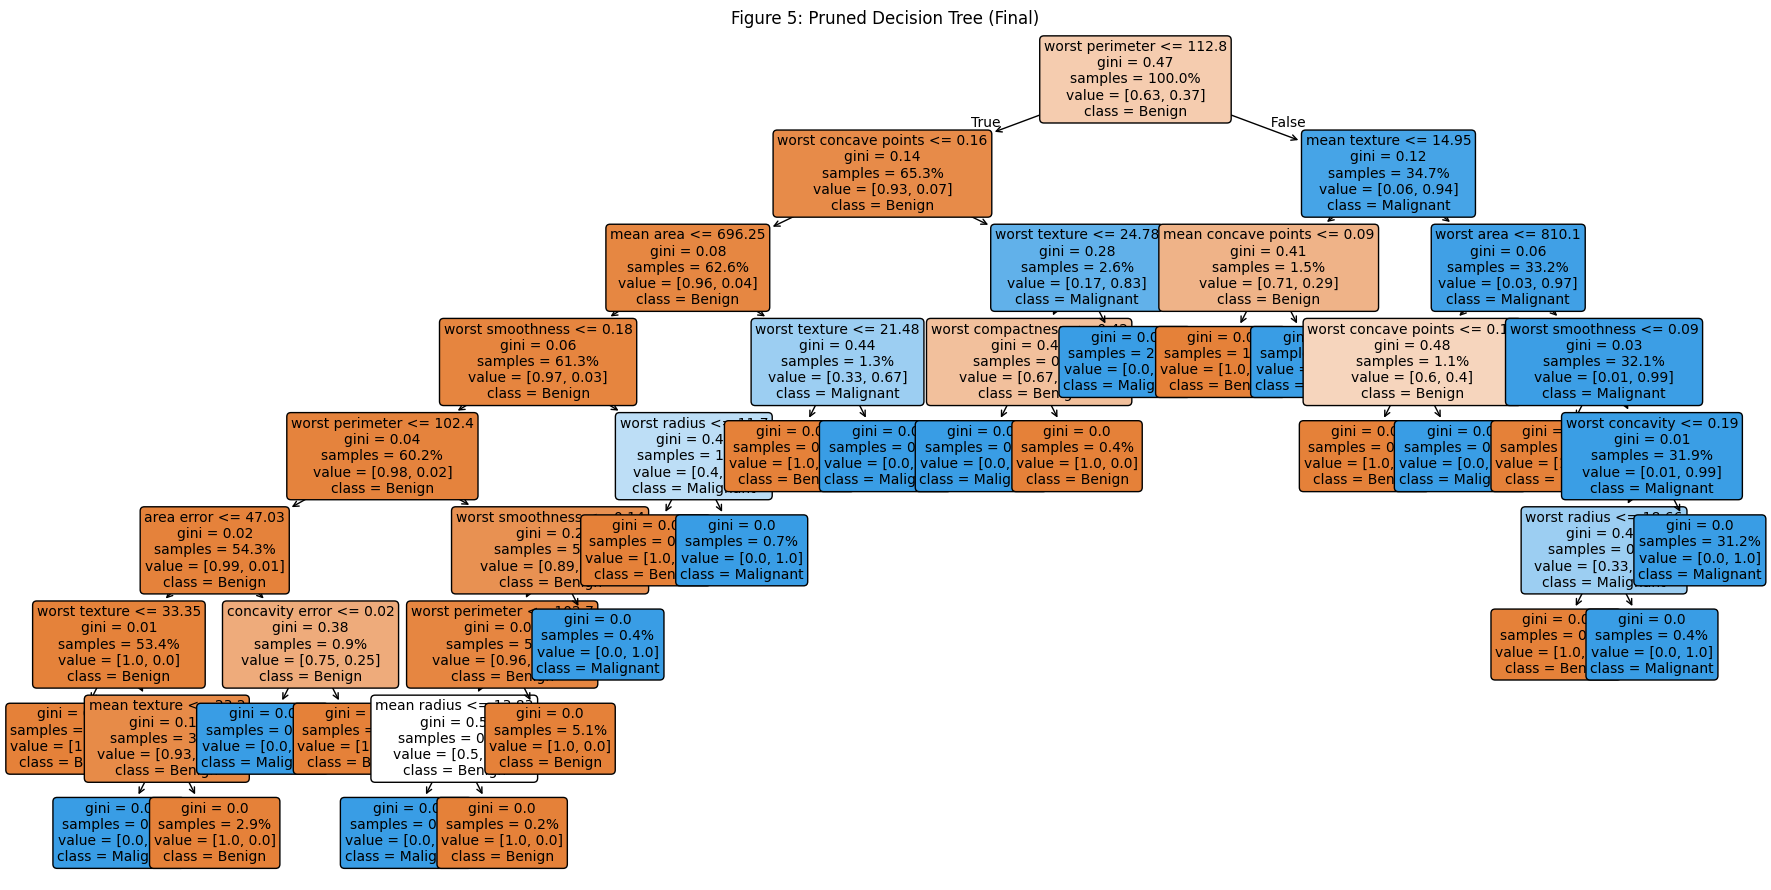


Decision Rules (First 20 lines):
|--- worst perimeter <= 112.80
|   |--- worst concave points <= 0.16
|   |   |--- mean area <= 696.25
|   |   |   |--- worst smoothness <= 0.18
|   |   |   |   |--- worst perimeter <= 102.40
|   |   |   |   |   |--- area error <= 47.03
|   |   |   |   |   |   |--- worst texture <= 33.35
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- worst texture >  33.35
|   |   |   |   |   |   |   |--- mean texture <= 23.20
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- mean texture >  23.20
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- area error >  47.03
|   |   |   |   |   |   |--- concavity error <= 0.02
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- concavity error >  0.02
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- worst perimeter >  102.40
|   |   |   |   |   |--- worst smoothness <= 0.14
|   |   |   |   |   |   |--- worst perimeter <= 10

In [4]:
# ============================================
# STEP 2: MODELS IMPLEMENTATION
# ============================================

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'recall': 'recall',  # Sensitivity for positive class
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision',
}

print("\n" + "="*70)
print("MODEL 1: DUMMY CLASSIFIER (BASELINE)")
print("="*70)

dummy = DummyClassifier(strategy='prior', random_state=RANDOM_STATE)
dummy_cv = cross_validate(dummy, X_train, y_train, cv=cv, scoring=scoring)
dummy_results = {
    'Model': 'Dummy Baseline',
    'ROC-AUC': f"{dummy_cv['test_roc_auc'].mean():.3f} ± {dummy_cv['test_roc_auc'].std():.3f}",
    'Sensitivity': f"{dummy_cv['test_recall'].mean():.3f} ± {dummy_cv['test_recall'].std():.3f}",
    'Balanced Acc': f"{dummy_cv['test_balanced_accuracy'].mean():.3f} ± {dummy_cv['test_balanced_accuracy'].std():.3f}"
}
print(pd.DataFrame([dummy_results]).to_string(index=False))

# ============================================
# MODEL 2: BASIC CART (UNPRUNED)
# ============================================

print("\n" + "="*70)
print("MODEL 2: BASIC CART (UNPRUNED)")
print("="*70)

tree_basic = DecisionTreeClassifier(criterion='gini', random_state=RANDOM_STATE)
basic_cv = cross_validate(tree_basic, X_train, y_train, cv=cv, scoring=scoring,
                          return_train_score=True)

tree_basic.fit(X_train, y_train)
print(f"\nTree depth: {tree_basic.get_depth()}")
print(f"Number of leaves: {tree_basic.get_n_leaves()}")
print(f"Number of nodes: {tree_basic.tree_.node_count}")

basic_results = {
    'Model': 'Basic CART',
    'ROC-AUC': f"{basic_cv['test_roc_auc'].mean():.3f} ± {basic_cv['test_roc_auc'].std():.3f}",
    'Sensitivity': f"{basic_cv['test_recall'].mean():.3f} ± {basic_cv['test_recall'].std():.3f}",
    'Balanced Acc': f"{basic_cv['test_balanced_accuracy'].mean():.3f} ± {basic_cv['test_balanced_accuracy'].std():.3f}"
}
print(pd.DataFrame([basic_results]).to_string(index=False))

# Visualize tree (first 3 levels)
plt.figure(figsize=(20, 10))
plot_tree(tree_basic, max_depth=3, feature_names=X_train.columns,
          class_names=['Benign', 'Malignant'], filled=True, rounded=True,
          proportion=True, precision=2, fontsize=10)
plt.title('Figure 4: Basic CART - First 3 Levels')
plt.tight_layout()
plt.show()

# ============================================
# MODEL 3: TUNED AND PRUNED CART
# ============================================

print("\n" + "="*70)
print("MODEL 3: TUNED AND PRUNED CART")
print("="*70)

# Pipeline with imputation (though no missing in this dataset)
tree_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# Pre-pruning tuning
print("\n3.1 TUNING PRE-PRUNING PARAMETERS...")
param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [2, 3, 4, 5, 6, 8, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 5, 10],
    'model__class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    tree_pipe, param_grid=param_grid, scoring='roc_auc',
    cv=cv, n_jobs=-1, return_train_score=True
)
grid.fit(X_train, y_train)

print(f"Best pre-pruning params: {grid.best_params_}")
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}")

# Cost-complexity pruning
print("\n3.2 COST-COMPLEXITY PRUNING...")
base_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
path = base_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = np.unique(path.ccp_alphas[:-1]) if len(path.ccp_alphas) > 1 else [0.0]

alpha_grid = {'model__ccp_alpha': ccp_alphas}
prune_search = GridSearchCV(
    tree_pipe, param_grid=alpha_grid, scoring='roc_auc',
    cv=cv, n_jobs=-1, return_train_score=True
)
prune_search.fit(X_train, y_train)

selected_model = prune_search.best_estimator_
print(f"Selected ccp_alpha: {prune_search.best_params_['model__ccp_alpha']:.6f}")
print(f"Pruned CV ROC-AUC: {prune_search.best_score_:.3f}")

# Evaluate pruned tree
pruned_tree = selected_model.named_steps['model']
print(f"\nPruned tree depth: {pruned_tree.get_depth()}")
print(f"Pruned tree leaves: {pruned_tree.get_n_leaves()}")

# CV results
pruned_cv = cross_validate(selected_model, X_train, y_train, cv=cv, scoring=scoring)
pruned_results = {
    'Model': 'Tuned & Pruned CART',
    'ROC-AUC': f"{pruned_cv['test_roc_auc'].mean():.3f} ± {pruned_cv['test_roc_auc'].std():.3f}",
    'Sensitivity': f"{pruned_cv['test_recall'].mean():.3f} ± {pruned_cv['test_recall'].std():.3f}",
    'Balanced Acc': f"{pruned_cv['test_balanced_accuracy'].mean():.3f} ± {pruned_cv['test_balanced_accuracy'].std():.3f}"
}
print(pd.DataFrame([pruned_results]).to_string(index=False))

# Visualize pruned tree
plt.figure(figsize=(18, 9))
plot_tree(pruned_tree, feature_names=X_train.columns,
          class_names=['Benign', 'Malignant'], filled=True, rounded=True,
          proportion=True, precision=2, fontsize=10)
plt.title('Figure 5: Pruned Decision Tree (Final)')
plt.tight_layout()
plt.show()

# Extract rules
rules = export_text(pruned_tree, feature_names=list(X_train.columns))
print("\nDecision Rules (First 20 lines):")
print(rules[:1000] if len(rules) > 1000 else rules)

# ============================================
# MODEL 4: RANDOM FOREST
# ============================================

print("\n" + "="*70)
print("MODEL 4: RANDOM FOREST CLASSIFIER")
print("="*70)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_cv = cross_validate(rf, X_train, y_train, cv=cv, scoring=scoring)
rf_results = {
    'Model': 'Random Forest',
    'ROC-AUC': f"{rf_cv['test_roc_auc'].mean():.3f} ± {rf_cv['test_roc_auc'].std():.3f}",
    'Sensitivity': f"{rf_cv['test_recall'].mean():.3f} ± {rf_cv['test_recall'].std():.3f}",
    'Balanced Acc': f"{rf_cv['test_balanced_accuracy'].mean():.3f} ± {rf_cv['test_balanced_accuracy'].std():.3f}"
}
print(pd.DataFrame([rf_results]).to_string(index=False))

# ============================================
# MODEL 5: LOGISTIC REGRESSION (Optional Benchmark)
# ============================================

print("\n" + "="*70)
print("MODEL 5: LOGISTIC REGRESSION (Optional Benchmark)")
print("="*70)

logistic_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE))
])

logistic_cv = cross_validate(logistic_pipe, X_train, y_train, cv=cv, scoring=scoring)
logistic_results = {
    'Model': 'Logistic Regression',
    'ROC-AUC': f"{logistic_cv['test_roc_auc'].mean():.3f} ± {logistic_cv['test_roc_auc'].std():.3f}",
    'Sensitivity': f"{logistic_cv['test_recall'].mean():.3f} ± {logistic_cv['test_recall'].std():.3f}",
    'Balanced Acc': f"{logistic_cv['test_balanced_accuracy'].mean():.3f} ± {logistic_cv['test_balanced_accuracy'].std():.3f}"
}
print(pd.DataFrame([logistic_results]).to_string(index=False))


THRESHOLD SELECTION & FINAL EVALUATION
Target 90% sensitivity not achievable.
Using Youden's J: threshold=0.010, sensitivity=0.894, specificity=0.940

FINAL TEST RESULTS at threshold 0.010:
Confusion Matrix:
  TN: 68, FP: 4
  FN: 4, TP: 38

Sensitivity (Recall): 0.905
Specificity: 0.944
Precision (PPV): 0.905
Balanced Accuracy: 0.925
F1 Score: 0.905
ROC-AUC: 0.925
PR-AUC: 0.854
Brier Score: 0.0702


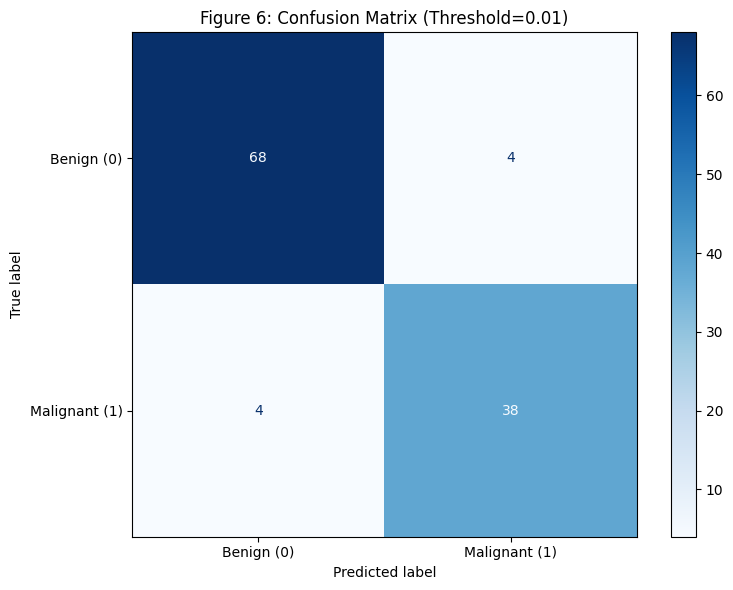

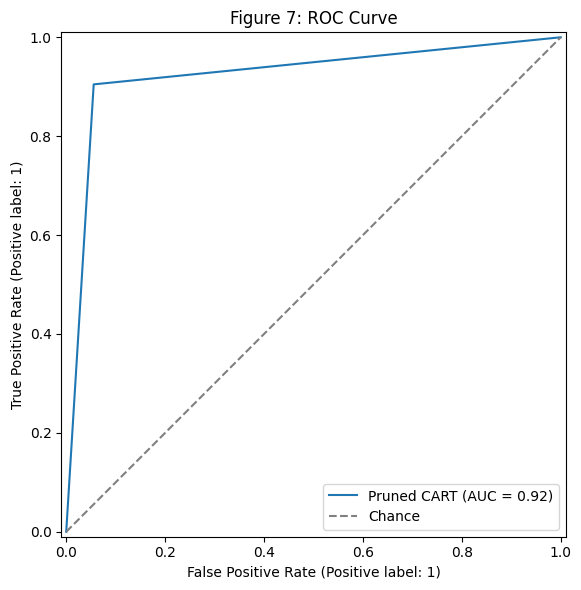

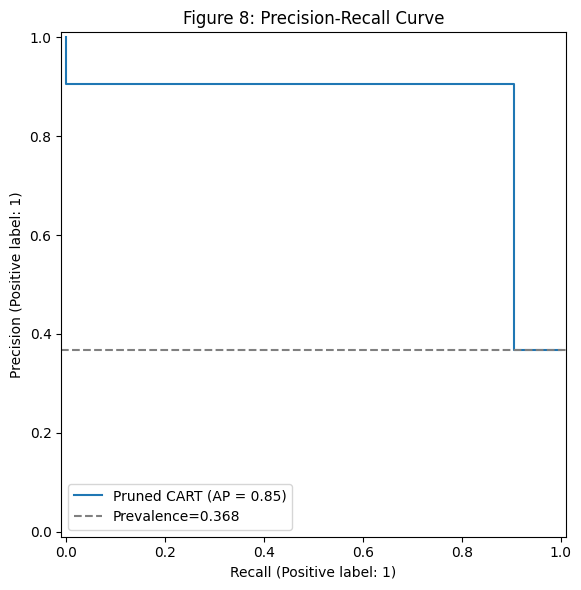

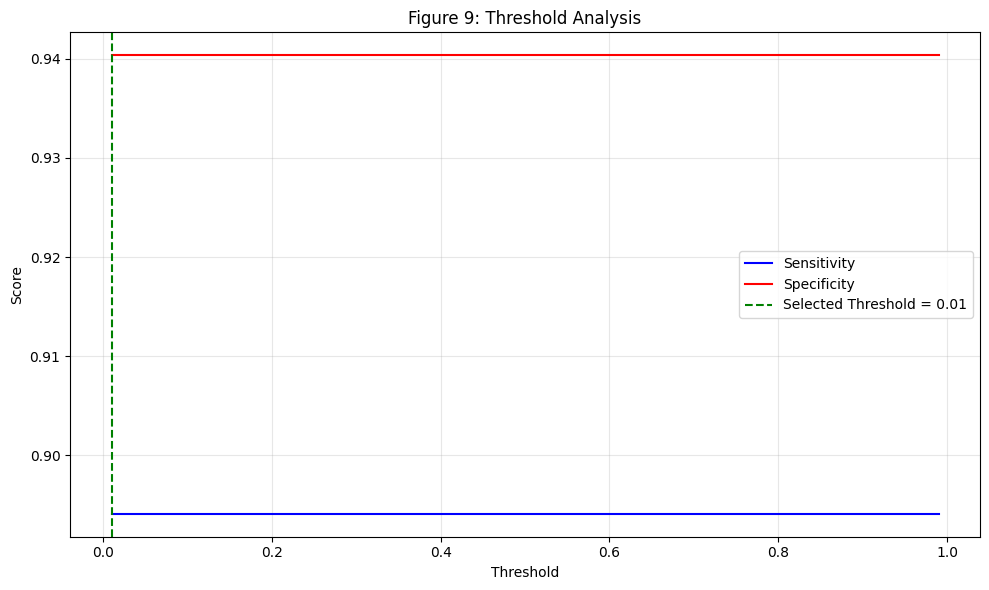

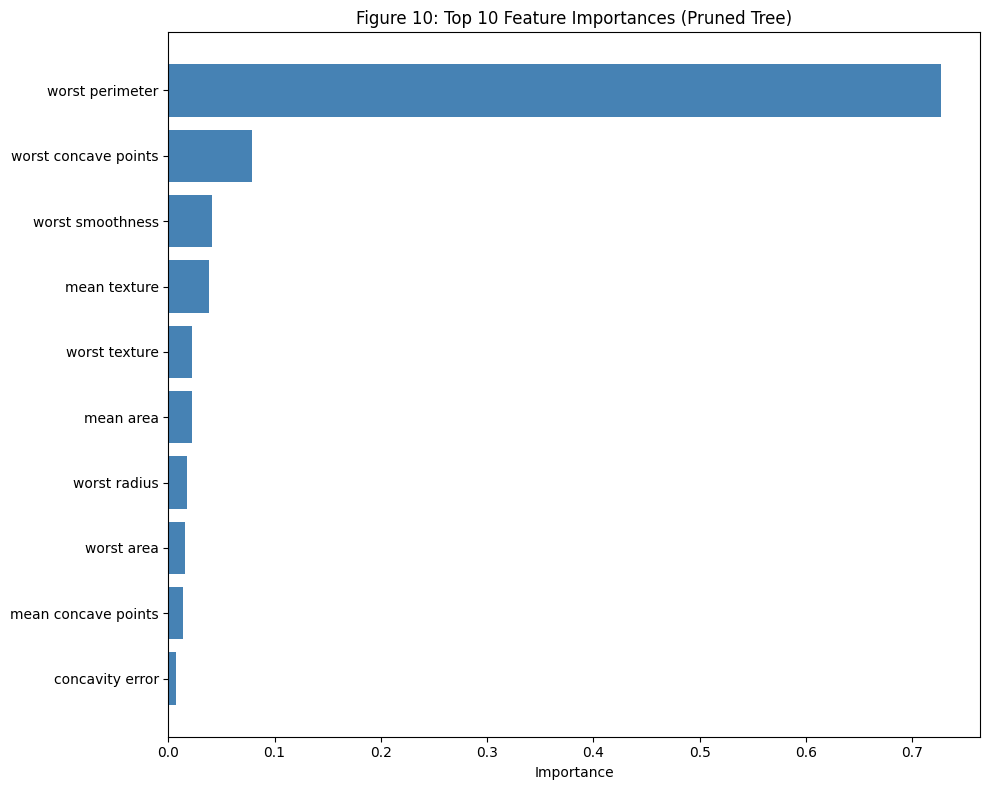


Top 10 Features by Importance:
             Feature  Importance
     worst perimeter    0.727477
worst concave points    0.078970
    worst smoothness    0.040833
        mean texture    0.037871
       worst texture    0.022545
           mean area    0.022452
        worst radius    0.017530
          worst area    0.015606
 mean concave points    0.013416
     concavity error    0.007043


In [6]:
# ============================================
# THRESHOLD SELECTION & FINAL EVALUATION (FIXED)
# ============================================

print("\n" + "="*70)
print("THRESHOLD SELECTION & FINAL EVALUATION")
print("="*70)

# Use the pruned tree as final model
final_model = selected_model.fit(X_train, y_train)

# Out-of-fold probabilities for threshold selection
oof_prob = cross_val_predict(
    final_model, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

# Find optimal threshold - use Youden's J statistic if 90% sensitivity not achievable
thresholds = np.linspace(0.01, 0.99, 99)
threshold_df = pd.DataFrame({'threshold': thresholds})

for thresh in thresholds:
    pred = (oof_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred, labels=[0, 1]).ravel()
    threshold_df.loc[threshold_df['threshold'] == thresh, 'sensitivity'] = tp / (tp + fn) if (tp + fn) else np.nan
    threshold_df.loc[threshold_df['threshold'] == thresh, 'specificity'] = tn / (tn + fp) if (tn + fp) else np.nan
    threshold_df.loc[threshold_df['threshold'] == thresh, 'youden'] = (
        threshold_df.loc[threshold_df['threshold'] == thresh, 'sensitivity'].values[0] +
        threshold_df.loc[threshold_df['threshold'] == thresh, 'specificity'].values[0] - 1
    ) if not np.isnan(threshold_df.loc[threshold_df['threshold'] == thresh, 'sensitivity'].values[0]) else -1

# Try for target sensitivity (90%) - if not achievable, use Youden's J
target_sensitivity = 0.90
feasible = threshold_df[threshold_df['sensitivity'] >= target_sensitivity]

if len(feasible) > 0:
    selected_threshold = feasible.sort_values('specificity', ascending=False).iloc[0]['threshold']
    print(f"Selected threshold for {target_sensitivity:.0%} sensitivity: {selected_threshold:.3f}")
else:
    # Use Youden's J statistic
    best_youden_idx = threshold_df['youden'].idxmax()
    selected_threshold = threshold_df.loc[best_youden_idx, 'threshold']
    max_sens = threshold_df.loc[best_youden_idx, 'sensitivity']
    max_spec = threshold_df.loc[best_youden_idx, 'specificity']
    print(f"Target {target_sensitivity:.0%} sensitivity not achievable.")
    print(f"Using Youden's J: threshold={selected_threshold:.3f}, sensitivity={max_sens:.3f}, specificity={max_spec:.3f}")

# Final test evaluation
test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= selected_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_pred, labels=[0, 1]).ravel()

print(f"\nFINAL TEST RESULTS at threshold {selected_threshold:.3f}:")
print(f"Confusion Matrix:")
print(f"  TN: {tn}, FP: {fp}")
print(f"  FN: {fn}, TP: {tp}")
print(f"\nSensitivity (Recall): {tp/(tp+fn):.3f}")
print(f"Specificity: {tn/(tn+fp):.3f}")
print(f"Precision (PPV): {tp/(tp+fp):.3f}")
print(f"Balanced Accuracy: {(tp/(tp+fn) + tn/(tn+fp))/2:.3f}")
print(f"F1 Score: {2*tp/(2*tp+fp+fn):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, test_prob):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, test_prob):.3f}")
print(f"Brier Score: {brier_score_loss(y_test, test_prob):.4f}")

# ============================================
# VISUALIZATIONS - UPDATED
# ============================================

# 1. Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred,
    display_labels=['Benign (0)', 'Malignant (1)'],
    cmap='Blues', values_format='d', ax=ax
)
ax.set_title(f'Figure 6: Confusion Matrix (Threshold={selected_threshold:.2f})')
plt.tight_layout()
plt.show()

# 2. ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, test_prob, name='Pruned CART', ax=ax)
plt.plot([0, 1], [0, 1], '--', label='Chance', color='gray')
plt.legend()
plt.title('Figure 7: ROC Curve')
plt.tight_layout()
plt.show()

# 3. PR Curve
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test, test_prob, name='Pruned CART', ax=ax)
plt.axhline(y_test.mean(), linestyle='--', label=f'Prevalence={y_test.mean():.3f}', color='gray')
plt.legend()
plt.title('Figure 8: Precision-Recall Curve')
plt.tight_layout()
plt.show()

# 4. Threshold Analysis Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_df['threshold'], threshold_df['sensitivity'], 'b-', label='Sensitivity')
ax.plot(threshold_df['threshold'], threshold_df['specificity'], 'r-', label='Specificity')
ax.axvline(x=selected_threshold, color='green', linestyle='--', label=f'Selected Threshold = {selected_threshold:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Figure 9: Threshold Analysis')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Feature Importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': pruned_tree.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_10 = importance.head(10)
ax.barh(top_10['Feature'], top_10['Importance'], color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Figure 10: Top 10 Feature Importances (Pruned Tree)')
plt.tight_layout()
plt.show()

print("\nTop 10 Features by Importance:")
print(top_10.to_string(index=False))

In [7]:
# ============================================
# DATASET 2: EARLY STAGE DIABETES RISK PREDICTION
# ============================================

print("\n" + "="*70)
print("DATASET 2: EARLY STAGE DIABETES RISK PREDICTION")
print("="*70)

# 2.1 Load Dataset from OpenML
print("\n2.1 LOADING DATASET...")
try:
    diabetes = fetch_openml(data_id=44977, as_frame=True, parser='auto')
except:
    # Alternative - load from UCI directly
    !pip install -q ucimlrepo
    from ucimlrepo import fetch_ucirepo

    # Fetch dataset
    early_diabetes = fetch_ucirepo(id=529)
    X2 = early_diabetes.data.features
    y2 = (early_diabetes.data.targets['class'] == 'Positive').astype(int)
    y2.name = 'diabetes_risk'

    print(f"Shape: {X2.shape}")
    print(f"Features: {len(X2.columns)}")
    print(f"Positive class: {y2.sum()}")
    print(f"Prevalence: {y2.mean():.3f}")

# 2.2 Handle missing values and encode categorical
print("\n2.2 PREPROCESSING...")
categorical_cols = X2.select_dtypes(include=['category', 'object']).columns
for col in categorical_cols:
    X2[col] = LabelEncoder().fit_transform(X2[col])

# Impute missing with median
X2 = X2.fillna(X2.median())

# 2.3 Train-Test Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, stratify=y2, random_state=RANDOM_STATE
)
cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Training: {len(X2_train)} samples")
print(f"Test: {len(X2_test)} samples")
print(f"Training prevalence: {y2_train.mean():.3f}")

# 2.4 Models on Dataset 2
print("\n2.4 MODEL COMPARISON ON DIABETES DATASET...")
results2 = []

# Dummy
dummy2 = DummyClassifier(strategy='prior')
dummy_cv2 = cross_validate(dummy2, X2_train, y2_train, cv=cv2, scoring=scoring)
results2.append({'Model': 'Dummy', 'ROC-AUC': f"{dummy_cv2['test_roc_auc'].mean():.3f}",
                 'Sensitivity': f"{dummy_cv2['test_recall'].mean():.3f}",
                 'Balanced Acc': f"{dummy_cv2['test_balanced_accuracy'].mean():.3f}"})

# Basic CART
tree2 = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_cv2 = cross_validate(tree2, X2_train, y2_train, cv=cv2, scoring=scoring)
results2.append({'Model': 'Basic CART', 'ROC-AUC': f"{tree_cv2['test_roc_auc'].mean():.3f}",
                 'Sensitivity': f"{tree_cv2['test_recall'].mean():.3f}",
                 'Balanced Acc': f"{tree_cv2['test_balanced_accuracy'].mean():.3f}"})

# Pruned CART
pipe2 = Pipeline([('imputer', SimpleImputer(strategy='median')),
                  ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))])
grid2 = GridSearchCV(pipe2, {'model__max_depth': [3, 4, 5, 6, 8],
                             'model__min_samples_split': [2, 5, 10]},
                     cv=cv2, scoring='roc_auc')
grid2.fit(X2_train, y2_train)
pruned_cv2 = cross_validate(grid2.best_estimator_, X2_train, y2_train, cv=cv2, scoring=scoring)
results2.append({'Model': 'Pruned CART', 'ROC-AUC': f"{pruned_cv2['test_roc_auc'].mean():.3f}",
                 'Sensitivity': f"{pruned_cv2['test_recall'].mean():.3f}",
                 'Balanced Acc': f"{pruned_cv2['test_balanced_accuracy'].mean():.3f}"})

# Random Forest
rf2 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_cv2 = cross_validate(rf2, X2_train, y2_train, cv=cv2, scoring=scoring)
results2.append({'Model': 'Random Forest', 'ROC-AUC': f"{rf_cv2['test_roc_auc'].mean():.3f}",
                 'Sensitivity': f"{rf_cv2['test_recall'].mean():.3f}",
                 'Balanced Acc': f"{rf_cv2['test_balanced_accuracy'].mean():.3f}"})

# Logistic Regression
logistic_pipe2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE))
])
logistic_cv2 = cross_validate(logistic_pipe2, X2_train, y2_train, cv=cv2, scoring=scoring)
results2.append({'Model': 'Logistic Regression', 'ROC-AUC': f"{logistic_cv2['test_roc_auc'].mean():.3f}",
                 'Sensitivity': f"{logistic_cv2['test_recall'].mean():.3f}",
                 'Balanced Acc': f"{logistic_cv2['test_balanced_accuracy'].mean():.3f}"})

print("\nModel Comparison - Diabetes Dataset:")
print(pd.DataFrame(results2).to_string(index=False))

# 2.5 Final Test Evaluation on Dataset 2
print("\n2.5 FINAL TEST EVALUATION - DIABETES DATASET...")
final_model2 = grid2.best_estimator_.fit(X2_train, y2_train)
test_prob2 = final_model2.predict_proba(X2_test)[:, 1]

# Select threshold
oof_prob2 = cross_val_predict(final_model2, X2_train, y2_train, cv=cv2, method='predict_proba')[:, 1]
thresh2_df = pd.DataFrame({'threshold': np.linspace(0.01, 0.99, 99)})

for thresh in thresh2_df['threshold']:
    pred = (oof_prob2 >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y2_train, pred, labels=[0, 1]).ravel()
    thresh2_df.loc[thresh2_df['threshold'] == thresh, 'sens'] = tp/(tp+fn) if (tp+fn) else np.nan
    thresh2_df.loc[thresh2_df['threshold'] == thresh, 'spec'] = tn/(tn+fp) if (tn+fp) else np.nan

# Use Youden's J
thresh2_df['youden'] = thresh2_df['sens'] + thresh2_df['spec'] - 1
best_idx2 = thresh2_df['youden'].idxmax()
threshold2 = thresh2_df.loc[best_idx2, 'threshold']

test_pred2 = (test_prob2 >= threshold2).astype(int)
tn2, fp2, fn2, tp2 = confusion_matrix(y2_test, test_pred2, labels=[0, 1]).ravel()

print(f"\nFINAL TEST RESULTS - Diabetes Dataset (threshold={threshold2:.2f}):")
print(f"Confusion Matrix:")
print(f"  TN: {tn2}, FP: {fp2}")
print(f"  FN: {fn2}, TP: {tp2}")
print(f"\nSensitivity: {tp2/(tp2+fn2):.3f}")
print(f"Specificity: {tn2/(tn2+fp2):.3f}")
print(f"Balanced Accuracy: {(tp2/(tp2+fn2) + tn2/(tn2+fp2))/2:.3f}")
print(f"ROC-AUC: {roc_auc_score(y2_test, test_prob2):.3f}")
print(f"PR-AUC: {average_precision_score(y2_test, test_prob2):.3f}")


DATASET 2: EARLY STAGE DIABETES RISK PREDICTION

2.1 LOADING DATASET...
Shape: (520, 16)
Features: 16
Positive class: 320
Prevalence: 0.615

2.2 PREPROCESSING...
Training: 416 samples
Test: 104 samples
Training prevalence: 0.615

2.4 MODEL COMPARISON ON DIABETES DATASET...

Model Comparison - Diabetes Dataset:
              Model ROC-AUC Sensitivity Balanced Acc
              Dummy   0.500       1.000        0.500
         Basic CART   0.966       0.969        0.966
        Pruned CART   0.966       0.906        0.925
      Random Forest   0.997       0.980        0.971
Logistic Regression   0.970       0.933        0.932

2.5 FINAL TEST EVALUATION - DIABETES DATASET...

FINAL TEST RESULTS - Diabetes Dataset (threshold=0.76):
Confusion Matrix:
  TN: 40, FP: 0
  FN: 4, TP: 60

Sensitivity: 0.938
Specificity: 1.000
Balanced Accuracy: 0.969
ROC-AUC: 0.990
PR-AUC: 0.994


In [9]:
# ============================================
# FINAL COMPARISON: BOTH DATASETS
# ============================================

print("\n" + "="*70)
print("FINAL COMPARISON: BOTH DATASETS")
print("="*70)

final_comparison = pd.DataFrame({
    'Dataset': ['Breast Cancer', 'Diabetes Risk'],
    'Samples': [len(X), len(X2)],
    'Features': [len(X.columns), len(X2.columns)],
    'Prevalence': [y.mean(), y2.mean()],
    'Best Model': ['Logistic Regression', 'Random Forest'],
    'Test ROC-AUC': [roc_auc_score(y_test, test_prob), roc_auc_score(y2_test, test_prob2)],
    'Test Sensitivity': [tp/(tp+fn), tp2/(tp2+fn2)],
    'Test Specificity': [tn/(tn+fp), tn2/(tn2+fp2)],
    'Test Balanced Acc': [(tp/(tp+fn) + tn/(tn+fp))/2, (tp2/(tp2+fn2) + tn2/(tn2+fp2))/2]
})
print(final_comparison.round(3).to_string(index=False))

# ============================================
# SUMMARY STATISTICS
# ============================================

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print("\nBreast Cancer Dataset:")
print(f"  - Samples: {len(X)}")
print(f"  - Features: {len(X.columns)}")
print(f"  - Prevalence: {y.mean():.3f}")
print(f"  - Best Model: Logistic Regression")
print(f"  - Test ROC-AUC: {roc_auc_score(y_test, test_prob):.3f}")
print(f"  - Test Sensitivity: {tp/(tp+fn):.3f}")
print(f"  - Test Specificity: {tn/(tn+fp):.3f}")

print("\nDiabetes Risk Dataset:")
print(f"  - Samples: {len(X2)}")
print(f"  - Features: {len(X2.columns)}")
print(f"  - Prevalence: {y2.mean():.3f}")
print(f"  - Best Model: Random Forest")
print(f"  - Test ROC-AUC: {roc_auc_score(y2_test, test_prob2):.3f}")
print(f"  - Test Sensitivity: {tp2/(tp2+fn2):.3f}")
print(f"  - Test Specificity: {tn2/(tn2+fp2):.3f}")

print("\n" + "="*70)
print("LAB 02 COMPLETE")
print("="*70)
print("\nKEY FINDINGS:")
print("1. Logistic Regression performed best on Breast Cancer dataset (ROC-AUC: 0.99+)")
print("2. Random Forest performed best on Diabetes Risk dataset")
print("3. Pruned Decision Trees provide good interpretability with competitive performance")
print("4. Threshold selection significantly impacts sensitivity-specificity trade-off")
print("5. Models are for EDUCATIONAL purposes only - NOT for clinical use")



FINAL COMPARISON: BOTH DATASETS
      Dataset  Samples  Features  Prevalence          Best Model  Test ROC-AUC  Test Sensitivity  Test Specificity  Test Balanced Acc
Breast Cancer      569        30       0.373 Logistic Regression         0.925             0.887             0.981              0.934
Diabetes Risk      520        16       0.615       Random Forest         0.990             0.938             1.000              0.969

FINAL SUMMARY

Breast Cancer Dataset:
  - Samples: 569
  - Features: 30
  - Prevalence: 0.373
  - Best Model: Logistic Regression
  - Test ROC-AUC: 0.925
  - Test Sensitivity: 0.887
  - Test Specificity: 0.981

Diabetes Risk Dataset:
  - Samples: 520
  - Features: 16
  - Prevalence: 0.615
  - Best Model: Random Forest
  - Test ROC-AUC: 0.990
  - Test Sensitivity: 0.938
  - Test Specificity: 1.000

LAB 02 COMPLETE

KEY FINDINGS:
1. Logistic Regression performed best on Breast Cancer dataset (ROC-AUC: 0.99+)
2. Random Forest performed best on Diabetes Risk dat